In [29]:
from SigProfilerExtractor import sigpro as sig
from SigProfilerMatrixGenerator import install as genInstall
import os
import sys
from pathlib import Path
from sigProfilerPlotting import plotSBS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shutil
from scipy import stats as scipy_stats
import matplotlib.colors as mcolors
from matplotlib.colors import TwoSlopeNorm
from itertools import permutations
from scipy.stats import rankdata, wilcoxon
from matplotlib.ticker import ScalarFormatter

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

In [2]:
genInstall.install('GRCh38', rsync=False, bash=True)

Tool       | Installed 
-----------------------
curl       | True      
wget       | False     
rsync      | True      


INFO - GRCh38 is already installed.


All reference files have been created.
To proceed with matrix_generation, please provide the path to your vcf files and an appropriate output path.
Installation complete.


# Plot Website Outputs

In [3]:
# CONFIGURE THESE PATHS
BASE_PATH = "/path/to/data/mutation_signatures/ONTWGS9"  # Directory containing sample folders
OUTPUT_DIR = "/path/to/data/mutation_signatures/ONTWGS9signature_contributions"  # Directory to save plots

# Create output directory if it doesn't exist
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

print(f"Input path: {BASE_PATH}")
print(f"Output path: {OUTPUT_DIR}")

Input path: /path/to/data/mutation_signatures/ONTWGS9
Output path: /path/to/data/mutation_signatures/ONTWGS9signature_contributions


In [31]:
PLOTSAVEDIR="/path/to/figures/"

In [5]:
def find_sample_directories(base_path):
    """
    Find all sample directories containing sbs_catalog.csv files.
    
    Args:
        base_path: Root directory containing sample folders
    
    Returns:
        Dictionary mapping sample_id to sample_path
    """
    base_path = Path(base_path)
    sample_dirs = {}
    
    for item in base_path.iterdir():
        if item.is_dir():
            sbs_catalog = item / "sbs_catalog.csv"
            if sbs_catalog.exists():
                sample_dirs[item.name] = item
    
    return sample_dirs

In [6]:
def plot_sample_sbs(sample_id, sample_path, output_dir):
    """
    Generate SBS plots for a single sample.
    
    Args:
        sample_id: Sample identifier
        sample_path: Path to sample directory
        output_dir: Directory to save output plots
    """
    sbs_catalog = sample_path / "sbs_catalog.csv"
    
    if not sbs_catalog.exists():
        print(f"Warning: {sbs_catalog} not found for {sample_id}")
        return
    
    # Create a temporary directory for this sample's plots
    temp_output = Path(output_dir) / f"temp_{sample_id}"
    temp_output.mkdir(parents=True, exist_ok=True)
    
    try:
        # Generate SBS plots using SigProfilerPlotting
        # Call plotSBS directly (it's already the function)
        plotSBS(
            matrix_path=str(sbs_catalog),
            output_path=str(temp_output),
            project=sample_id,
            plot_type='96',  # 96-channel SBS plot
            percentage=False  # Use absolute counts
        )
        
        # Move and rename plots to flat structure
        plot_dir = temp_output / "SBS_96"
        if plot_dir.exists():
            for plot_file in plot_dir.glob("*"):
                if plot_file.is_file():
                    # Rename to flat structure
                    ext = plot_file.suffix
                    new_name = f"{sample_id}_sbs_96{ext}"
                    new_path = Path(output_dir) / new_name
                    plot_file.rename(new_path)
                    print(f"✓ Created: {new_path}")
        
        # Clean up temp directory
        shutil.rmtree(temp_output)
        
    except Exception as e:
        print(f"Error processing {sample_id}: {e}")
        import traceback
        traceback.print_exc()
        # Clean up temp directory even on error
        if temp_output.exists():
            shutil.rmtree(temp_output)

In [7]:
def plot_contributions(sample_id, sample_path, output_dir):
    """
    Generate signature contribution plots similar to Signal's Advanced Details.
    Shows box plots of bootstrap distributions with median contributions,
    sparsity filter threshold, and excluded signatures.
    
    Args:
        sample_id: Sample identifier
        sample_path: Path to sample directory
        output_dir: Directory to save output plots
    """
    # Check for SBS signatures directory
    sbs_sig_dir = sample_path / "sbs_signatures"
    if not sbs_sig_dir.exists():
        return
    
    # Look for solution directories (numbered 1, 2, 3, etc.)
    for solution_dir in sorted(sbs_sig_dir.iterdir()):
        if solution_dir.is_dir() and solution_dir.name.isdigit():
            contributions_file = solution_dir / "contributions.csv"
            bootstraps_file = solution_dir / "bootstraps.csv"
            
            if not contributions_file.exists():
                continue
                
            try:
                # Read median contributions
                contrib = pd.read_csv(contributions_file, index_col=0)
                
                # Read bootstrap distributions if available
                if bootstraps_file.exists():
                    bootstraps = pd.read_csv(bootstraps_file, index_col=0)
                    
                    # Calculate sparsity threshold (typically small percentage of total mutations)
                    # You can adjust this - common values are 1-5% of total mutations
                    total_mutations = contrib['Contribution'].sum()
                    sparsity_threshold = total_mutations * 0.01  # 1% of total
                    # Alternative: use a fixed value like 100 mutations
                    # sparsity_threshold = 100
                    
                    # Determine which signatures are below threshold in significant fraction
                    # Count how many bootstrap solutions are below threshold for each signature
                    p_value_threshold = 0.05  # 5% significance
                    signatures = bootstraps.index.tolist()
                    excluded_sigs = []
                    
                    for sig in signatures:
                        bootstrap_values = bootstraps.loc[sig].values
                        fraction_below = (bootstrap_values < sparsity_threshold).sum() / len(bootstrap_values)
                        if fraction_below > p_value_threshold:
                            excluded_sigs.append(sig)
                    
                    # Create box plot with bootstrap distributions
                    fig, ax = plt.subplots(figsize=(14, 7))
                    
                    # Prepare data for box plot
                    box_data = [bootstraps.loc[sig].values for sig in signatures]
                    box_positions = list(range(len(signatures)))
                    
                    # Create box plots
                    bp = ax.boxplot(box_data, positions=box_positions, 
                                   widths=0.6, patch_artist=True,
                                   showfliers=False)
                    
                    # Style the boxes - color based on exclusion status
                    for i, (patch, sig) in enumerate(zip(bp['boxes'], signatures)):
                        if sig in excluded_sigs:
                            # Red background for excluded signatures
                            patch.set_facecolor('#ffcccc')
                            patch.set_alpha(0.8)
                        else:
                            # Blue for included signatures
                            patch.set_facecolor('lightblue')
                            patch.set_alpha(0.7)
                    
                    # Add red background rectangles for excluded signatures
                    y_max = ax.get_ylim()[1]
                    for i, sig in enumerate(signatures):
                        if sig in excluded_sigs:
                            ax.axvspan(i - 0.4, i + 0.4, alpha=0.15, color='red', zorder=0)
                    
                    # Plot median contributions as X markers
                    for i, sig in enumerate(signatures):
                        median_val = contrib.loc[sig, 'Contribution']
                        if sig in excluded_sigs:
                            # Red X for excluded signatures
                            ax.plot(i, median_val, 'rx', markersize=14, markeredgewidth=3)
                        else:
                            # Black X for included signatures
                            ax.plot(i, median_val, 'kx', markersize=14, markeredgewidth=3)
                    
                    # Add sparsity threshold line (green dashed)
                    ax.axhline(y=sparsity_threshold, color='green', linestyle='--', 
                              linewidth=2, label=f'Sparsity filter threshold ({sparsity_threshold:.1f})')
                    
                    ax.set_xlabel('Signature', fontsize=12, fontweight='bold')
                    ax.set_ylabel('Contribution (count)', fontsize=12, fontweight='bold')
                    ax.set_title(f'{sample_id} - Signature Contributions with Bootstrap Distributions (Solution {solution_dir.name})', 
                                fontsize=14, fontweight='bold')
                    ax.set_xticks(box_positions)
                    ax.set_xticklabels(signatures, rotation=45, ha='right', fontsize=11)
                    ax.grid(axis='y', alpha=0.3, linestyle='--')
                    ax.legend(loc='upper right', fontsize=10)
                    
                    # Add text note about excluded signatures
                    if excluded_sigs:
                        excluded_text = f"Excluded signatures (red): {', '.join(excluded_sigs)}"
                        ax.text(0.02, 0.98, excluded_text, transform=ax.transAxes,
                               fontsize=9, verticalalignment='top',
                               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
                    
                    plt.tight_layout()
                    
                    output_file = Path(output_dir) / f"{sample_id}_bootstrap_contributions_sol{solution_dir.name}.png"
                    plt.savefig(output_file, dpi=300, bbox_inches='tight')
                    plt.close()
                    print(f"✓ Created: {output_file}")
                    
                else:
                    # Fallback: simple bar plot if no bootstrap data
                    fig, ax = plt.subplots(figsize=(12, 6))
                    contrib.plot(kind='bar', y='Contribution', ax=ax, legend=False)
                    ax.set_xlabel('Signature')
                    ax.set_ylabel('Mutations')
                    ax.set_title(f'{sample_id} - Signature Contributions (Solution {solution_dir.name})')
                    plt.tight_layout()
                    
                    output_file = Path(output_dir) / f"{sample_id}_contributions_sol{solution_dir.name}.png"
                    plt.savefig(output_file, dpi=300, bbox_inches='tight')
                    plt.close()
                    print(f"✓ Created: {output_file}")
                    
            except Exception as e:
                print(f"Error plotting contributions for {sample_id} solution {solution_dir.name}: {e}")
                import traceback
                traceback.print_exc()

In [8]:
# Find all sample directories
sample_dirs = find_sample_directories(BASE_PATH)

if not sample_dirs:
    print(f"No sample directories with sbs_catalog.csv found in {BASE_PATH}")
else:
    print(f"✓ Found {len(sample_dirs)} samples to process:")
    print("-" * 60)
    for sample_id in sorted(sample_dirs.keys()):
        print(f"  - {sample_id}")

✓ Found 15 samples to process:
------------------------------------------------------------
  - ONTWGS9-1-238701-NP01
  - ONTWGS9-10-240188-NP01
  - ONTWGS9-11-240189-NP01
  - ONTWGS9-12-240190-NP01
  - ONTWGS9-13-240191-NP01
  - ONTWGS9-14-240192-NP01
  - ONTWGS9-15-240193-NP01
  - ONTWGS9-2-238702-NP01
  - ONTWGS9-3-238703-NP01
  - ONTWGS9-4-240182-NP01
  - ONTWGS9-5-240183-NP01
  - ONTWGS9-6-240184-NP01
  - ONTWGS9-7-240185-NP01
  - ONTWGS9-8-240186-NP01
  - ONTWGS9-9-240187-NP01


In [9]:
# Preview the file structure
if sample_dirs:
    first_sample = list(sample_dirs.keys())[0]
    
    # Check contributions
    contrib_path = sample_dirs[first_sample] / "sbs_signatures" / "1" / "contributions.csv"
    if contrib_path.exists():
        print("=== CONTRIBUTIONS.CSV ===")
        contrib = pd.read_csv(contrib_path, index_col=0)
        print(contrib)
        print(f"\nShape: {contrib.shape}")
        print(f"Index: {contrib.index.tolist()}")
        print(f"Columns: {contrib.columns.tolist()}")
    
    # Check bootstraps
    bootstrap_path = sample_dirs[first_sample] / "sbs_signatures" / "1" / "bootstraps.csv"
    if bootstrap_path.exists():
        print("\n=== BOOTSTRAPS.CSV ===")
        bootstraps = pd.read_csv(bootstrap_path, index_col=0)
        print(bootstraps.head(10))
        print(f"\nShape: {bootstraps.shape}")
        print(f"Index: {bootstraps.index.tolist()[:10]}")
        print(f"Columns: {bootstraps.columns.tolist()}")

=== CONTRIBUTIONS.CSV ===
            Contribution
Signature               
SBS1           3927.6640
SBS2              0.0000
SBS3           2302.1270
SBS5          14967.4400
SBS8              0.0000
SBS13             0.0000
SBS17             0.0000
SBS18             0.0000
Unassigned      554.7678

Shape: (9, 1)
Index: ['SBS1', 'SBS2', 'SBS3', 'SBS5', 'SBS8', 'SBS13', 'SBS17', 'SBS18', 'Unassigned']
Columns: ['Contribution']

=== BOOTSTRAPS.CSV ===
            Solution_1  Solution_2   Solution_3  Solution_4  Solution_5  \
Signature                                                                 
SBS1        3874.34600   3828.8710   4140.74600   3853.2470   3674.4750   
SBS2         147.40480    103.5847    162.16590    239.6786    189.2991   
SBS3        2493.62000   2292.7130   2384.00900   2558.6640   2137.2330   
SBS5       14866.31000  15124.0300  14704.78000  14770.5600  15350.1700   
SBS8           0.00000      0.0000      0.00000      0.0000      0.0000   
SBS13         63.900

In [10]:
# Process each sample
print("Starting batch processing...")
print("=" * 60)

for sample_id, sample_path in sorted(sample_dirs.items()):
    print(f"\n Processing: {sample_id}")
    print("-" * 60)
    
    # Plot SBS catalog
    plot_sample_sbs(sample_id, sample_path, OUTPUT_DIR)
    
    # Plot signature contributions if available
    plot_contributions(sample_id, sample_path, OUTPUT_DIR)

print("\n" + "=" * 60)
print(f"✓ Processing complete! Plots saved to: {OUTPUT_DIR}")
print("=" * 60)

Starting batch processing...

 Processing: ONTWGS9-1-238701-NP01
------------------------------------------------------------
✓ Created: /path/to/data/mutation_signatures/ONTWGS9signature_contributions/ONTWGS9-1-238701-NP01_bootstrap_contributions_sol1.png

 Processing: ONTWGS9-10-240188-NP01
------------------------------------------------------------
✓ Created: /path/to/data/mutation_signatures/ONTWGS9signature_contributions/ONTWGS9-10-240188-NP01_bootstrap_contributions_sol1.png

 Processing: ONTWGS9-11-240189-NP01
------------------------------------------------------------
✓ Created: /path/to/data/mutation_signatures/ONTWGS9signature_contributions/ONTWGS9-11-240189-NP01_bootstrap_contributions_sol1.png

 Processing: ONTWGS9-12-240190-NP01
------------------------------------------------------------
✓ Created: /path/to/data/mutation_signatures/ONTWGS9signature_contributions/ONTWGS9-12-240190-NP01_bootstrap_contributions_sol1.png

 Processing: ONTWGS9-13-240191-NP01
----------------

In [11]:
# Preview first sample's catalog
if sample_dirs:
    first_sample = list(sample_dirs.keys())[4]
    catalog_path = sample_dirs[first_sample] / "sbs_catalog.csv"
    
    print(f"Preview of {first_sample} SBS catalog:")
    print("=" * 60)
    
    catalog = pd.read_csv(catalog_path, index_col=0)
    print(f"Shape: {catalog.shape}")
    print(f"\nFirst few rows:")
    display(catalog.head(10))
    
    print(f"\nTotal mutations per sample:")
    print(catalog.sum())

Preview of ONTWGS9-1-238701-NP01 SBS catalog:
Shape: (96, 1)

First few rows:


,ONTWGS9-1-238701-NP01
Substitution,
A[C>A]A,237
A[C>A]C,275
A[C>A]G,45
A[C>A]T,173
C[C>A]A,177
C[C>A]C,142
C[C>A]G,50
C[C>A]T,119
G[C>A]A,193



Total mutations per sample:
ONTWGS9-1-238701-NP01    23626
dtype: int64


In [12]:
# Preview contributions from first sample
if sample_dirs:
    first_sample = list(sample_dirs.keys())[-4]
    contrib_path = sample_dirs[first_sample] / "sbs_signatures" / "1" / "contributions.csv"
    
    if contrib_path.exists():
        print(f"Preview of {first_sample} contributions (Solution 1):")
        print("=" * 60)
        
        contrib = pd.read_csv(contrib_path, index_col=0)
        print(f"Shape: {contrib.shape}")
        print(f"\nSignature contributions:")
        display(contrib)
    else:
        print(f"No contributions file found for {first_sample}")

Preview of ONTWGS9-5-240183-NP01 contributions (Solution 1):
Shape: (9, 1)

Signature contributions:


,Contribution
Signature,
SBS1,1515.696
SBS2,0.000
SBS3,1022.646
SBS5,5832.516
SBS8,0.000
SBS13,0.000
SBS17,0.000
SBS18,0.000
Unassigned,326.142


### Sonopet study specific

In [13]:
SEQID_TO_SR = {
    1:  "1S",  2:  "1R",
    3:  "2S",            # patient 2 – no resection, skip pairing
    4:  "3R",  5:  "3S",
    6:  "4R",  7:  "4S",
    8:  "5R",  9:  "5S",
    10: "6R",  11: "6S",
    12: "7R",  13: "7S",
    14: "8R",  15: "8S",
}

In [25]:
# ── Shared plot config ─────────────────────────────────────────────────────────
PLOT_CFG = dict(
    figsize          = (6, 6),
    scatter_s        = 200,
    diagonal_kw      = dict(linestyle="--", color="gray"),
    legend_kw = dict(frameon=True, framealpha=0.7, facecolor="white"),
    fontsize_title   = 20,
    fontsize_label   = 19,
    fontsize_tick    = 15,
    fontsize_legend  = 15,
    corr_fontsize    = 15,
    corr_bbox_kw     = dict(boxstyle="round,pad=0.3", facecolor="white",
                            edgecolor="lightgrey", alpha=0.8),
    show_ci   = True,   # show bootstrap CIs
    ci_level  = 0.95,
    ci_n_boot = 5000,
    ci_seed   = 0,
    exact_p = True, # no rounding to 0.001       
)

def _save_fig(fig, path, fmt="pdf"):
    """Save fig to path, appending the correct extension."""
    if path is None:
        return
    ext_map = {"pdf": ".pdf", "png": ".png"}
    ext = ext_map.get(fmt, f".{fmt}")
    full_path = f"{path}{ext}"
    kw = dict(format=fmt, bbox_inches="tight")
    if fmt == "png":
        kw["dpi"] = 300
    fig.savefig(full_path, **kw)

def _add_correlation(ax, x_vals, y_vals, patients=None, exclude=(3, 6),
                     show_ci=None, show_ccc=False, show_paired=False):

    x_vals = np.asarray(x_vals, dtype=float)
    y_vals = np.asarray(y_vals, dtype=float)
    if len(x_vals) < 3:
        return

    if show_ci is None:
        show_ci = PLOT_CFG.get("show_ci", False)
    ci     = PLOT_CFG.get("ci_level", 0.95)
    n_boot = PLOT_CFG.get("ci_n_boot", 5000)
    seed   = PLOT_CFG.get("ci_seed", 0)
    exact  = PLOT_CFG.get("exact_p", True)

    def _spearman_rho(rx, ry):
        return np.corrcoef(rx, ry)[0, 1]

    def _spearman_exact_p(x, y):
        r_obs, p_asym = scipy_stats.spearmanr(x, y)
        n = len(x)
        if not (exact and 3 <= n <= 8) or np.isnan(r_obs):
            return r_obs, p_asym
        rx, ry = rankdata(x), rankdata(y)
        count = tot = 0
        for perm in permutations(ry):
            tot += 1
            if abs(_spearman_rho(rx, np.array(perm))) >= abs(r_obs) - 1e-12:
                count += 1
        return r_obs, count / tot

    def _lin_ccc(x, y):
        mx, my = x.mean(), y.mean()
        sxy = ((x - mx) * (y - my)).mean()
        denom = x.var() + y.var() + (mx - my) ** 2
        return 2 * sxy / denom if denom > 0 else np.nan

    def _boot_ci(x, y, stat_fn):
        '''
        Bootstrap CI: patients are resampled with replacement as R-S pairs
        (N = n_boot resamples, random seed fixed by `seed`). The statistic is
        recomputed on each resample, and the (1-ci)/2 and (1+ci)/2 percentiles
        (2.5th and 97.5th for ci = 0.95) are taken as the interval.
        Resamples where R or S is constant are discarded (statistic undefined).
        rng = np.random.default_rng(seed)
        '''
        rng = np.random.default_rng(seed)
        n = len(x)
        boots = []
        for _ in range(n_boot):
            s = rng.integers(0, n, n)
            if np.unique(x[s]).size < 2 or np.unique(y[s]).size < 2:
                continue
            v = stat_fn(x[s], y[s])
            if not np.isnan(v):
                boots.append(v)
        if not boots:
            return None
        return (np.percentile(boots, (1 - ci) / 2 * 100),
                np.percentile(boots, (1 + ci) / 2 * 100))

    def _paired_text(x, y):
        # Matched-pair agreement: Wilcoxon signed-rank on R - S, plus
        # Bland-Altman bias and 95% limits of agreement.
        d = y - x
        if np.any(d != 0):
            _, p_w = wilcoxon(x, y)
            p_w_str = f"p = {p_w:.3f}" if p_w >= 0.001 else "p < 0.001"
        else:
            p_w_str = "p = n/a"
        bias = d.mean()
        sd   = d.std(ddof=1)
        return (f"Wilcoxon signed-rank {p_w_str}\n"
                f"Bias = {bias:.2f}, LoA [{bias - 1.96*sd:.2f}, {bias + 1.96*sd:.2f}]")

    def _metric_text(x, y):
        if show_ccc:
            txt   = f"CCC = {_lin_ccc(x, y):.2f}"
            ci_fn = _lin_ccc
        else:
            r, p = _spearman_exact_p(x, y)
            p_str = f"p = {p:.3f}" if p >= 0.001 else "p < 0.001"
            txt   = f"ρ = {r:.2f}, {p_str}"
            ci_fn = lambda a, c: _spearman_rho(rankdata(a), rankdata(c))
        if show_ci:
            b = _boot_ci(x, y, ci_fn)
            if b:
                txt += f"\n{int(ci*100)}% CI [{b[0]:.2f}, {b[1]:.2f}]"
        if show_paired:
            txt += f"\n{_paired_text(x, y)}"
        return txt

    head  = "Lin's" if show_ccc else "Spearman"
    lines = [f"{head} {_metric_text(x_vals, y_vals)}"]

    if patients is not None:
        patients = np.asarray([int(float(pp)) for pp in patients])
        mask = ~np.isin(patients, exclude)
        # if mask.sum() >= 3:
        #     lines.append(f"excl. P3/P6: {_metric_text(x_vals[mask], y_vals[mask])}")

    ax.text(0.05, 0.95, "\n".join(lines), transform=ax.transAxes,
            ha="left", va="top", fontsize=PLOT_CFG["corr_fontsize"],
            bbox=PLOT_CFG["corr_bbox_kw"])

def _scatter_with_diagonal(ax, df, x_col, y_col, colors, show_ccc=False, show_paired=False):
    for _, row in df.iterrows():
        p = row["patient"]
        ax.scatter(row[x_col], row[y_col],
                   color=colors[p], label=f"P{int(p)}", s=PLOT_CFG["scatter_s"])
    vals = df[[x_col, y_col]].values.flatten()
    lo, hi = vals.min(), vals.max()
    ax.plot([lo, hi], [lo, hi], **PLOT_CFG["diagonal_kw"])
    ax.legend(**PLOT_CFG["legend_kw"], fontsize=PLOT_CFG["fontsize_legend"])
    ax.tick_params(labelsize=PLOT_CFG["fontsize_tick"])
    _add_correlation(ax, df[x_col].values, df[y_col].values,
                     show_ccc=show_ccc, show_paired=show_paired)

def _scatter_with_crosshair(ax, df, x_col, y_col, colors):
    for _, row in df.iterrows():
        p = row["patient"]
        ax.scatter(row[x_col], row[y_col],
                   color=colors[p], label=f"P{int(p)}", s=PLOT_CFG["scatter_s"])
    ax.axhline(0, **PLOT_CFG["diagonal_kw"])
    ax.axvline(0, **PLOT_CFG["diagonal_kw"])
    ax.legend(**PLOT_CFG["legend_kw"], fontsize=PLOT_CFG["fontsize_legend"])
    ax.tick_params(labelsize=PLOT_CFG["fontsize_tick"])
    _add_correlation(ax, df[x_col].values, df[y_col].values)

In [27]:
def plot_total_mutation_burden(sample_dirs, seqid_to_sr=SEQID_TO_SR, skip_patients=("2",),
                               save_path=None, fmt="pdf", show_ccc=False, show_paired=False):
    from collections import defaultdict
    import re

    def _seqid(name):
        m = re.search(r"ONTWGS[^-]*-(\d+)-", str(name))
        return int(m.group(1)) if m else None

    seqid_to_total = {}
    for sample_name, sample_path in sample_dirs.items():
        sid = _seqid(sample_name)
        if sid is None:
            continue
        catalog_path = sample_path / "sbs_catalog.csv"
        if not catalog_path.exists():
            continue
        catalog = pd.read_csv(catalog_path, index_col=0)
        seqid_to_total[sid] = int(catalog.sum().sum())

    buckets = defaultdict(dict)
    for seqid, label in seqid_to_sr.items():
        patient, sr = label[:-1], label[-1]
        buckets[patient][sr] = seqid

    rows = []
    for patient in sorted(buckets, key=lambda x: int(x)):
        if patient in skip_patients:
            continue
        b = buckets[patient]
        if "S" not in b or "R" not in b:
            continue
        s_total = seqid_to_total.get(b["S"])
        r_total = seqid_to_total.get(b["R"])
        if s_total is None or r_total is None:
            print(f"  Patient {patient}: missing catalog, skipping.")
            continue
        rows.append({"patient": patient, "S_total": s_total, "R_total": r_total})

    df = pd.DataFrame(rows)
    df["Δ_total"] = df["R_total"] - df["S_total"]

    fig, ax = plt.subplots(figsize=PLOT_CFG["figsize"])
    ax.tick_params(axis="both", which="major", labelsize=PLOT_CFG["fontsize_tick"])

    formatter = ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((0, 0))
    ax.xaxis.set_major_formatter(formatter)
    ax.yaxis.set_major_formatter(formatter)

    for _, row in df.iterrows():
        p = row["patient"]
        ax.scatter(row["S_total"], row["R_total"], label=f"P{p}", s=PLOT_CFG["scatter_s"])

    all_vals = pd.concat([df["S_total"], df["R_total"]])
    mn, mx = all_vals.min(), all_vals.max()
    ax.plot([mn, mx], [mn, mx], **PLOT_CFG["diagonal_kw"])

    ax.set_xlabel("Total Mutation Burden (S)", fontsize=PLOT_CFG["fontsize_label"])
    ax.set_ylabel("Total Mutation Burden (R)", fontsize=PLOT_CFG["fontsize_label"])
    ax.set_title("Total Mutation Burden: R vs S",  fontsize=PLOT_CFG["fontsize_title"])
    ax.legend(**PLOT_CFG["legend_kw"],             fontsize=PLOT_CFG["fontsize_legend"])

    ax.set_facecolor("white")
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor("black")
        spine.set_linewidth(1.0)

    # in plot_total_mutation_burden
    _add_correlation(ax, df["S_total"].values, df["R_total"].values,
                     patients=df["patient"].values, show_ccc=show_ccc,
                     show_paired=show_paired)

    plt.tight_layout()
    _save_fig(fig, save_path, fmt)
    plt.show()

    return df[["patient", "S_total", "R_total", "Δ_total"]]

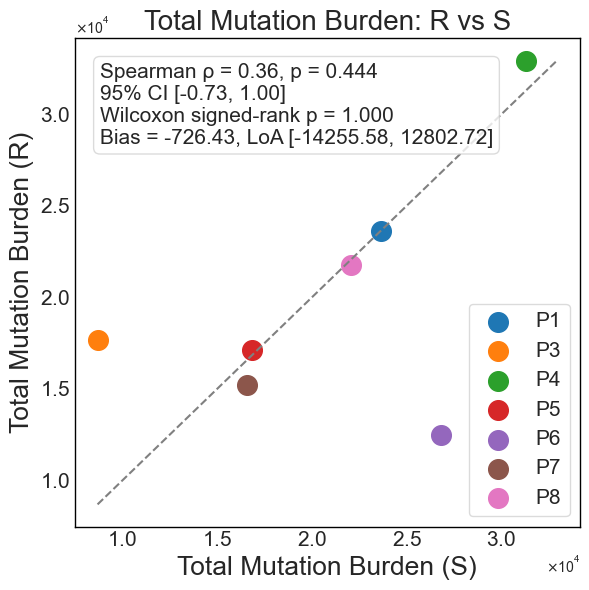

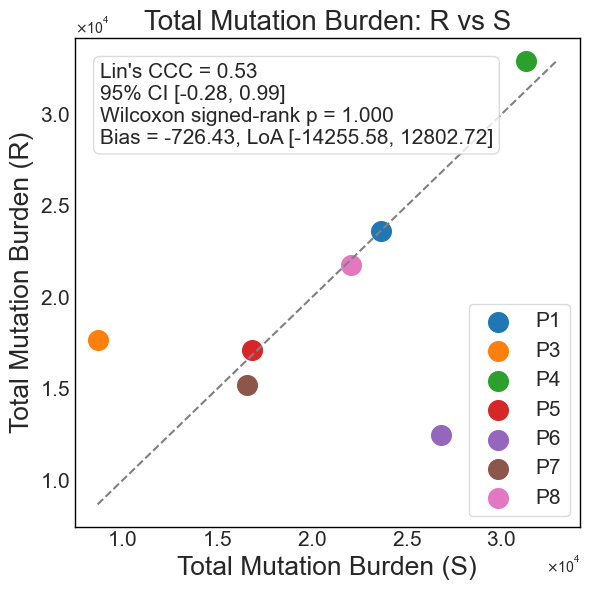

,patient,S_total,R_total,Δ_total
0,1,23626,23651,25
1,3,8697,17695,8998
2,4,31314,32934,1620
3,5,16866,17111,245
4,6,26795,12513,-14282
5,7,16596,15242,-1354
6,8,22089,21752,-337


In [32]:
# Spearman + exact p + CI
plot_total_mutation_burden(sample_dirs, save_path=f"{PLOTSAVEDIR}total_mutation_burden_ci", show_paired=True)

# Lin's CCC + CI
plot_total_mutation_burden(sample_dirs, show_ccc=True, save_path=f"{PLOTSAVEDIR}total_mutation_burden_ccc_ci", show_paired=True)

In [34]:
def plot_signature_r_vs_s(
    sample_dirs,
    signature,
    seqid_to_sr   = SEQID_TO_SR,
    skip_patients = ("2",),
    solution      = "1",
    normalise     = True,
    save_path     = None,
    fmt           = "pdf",
    show_ccc      = False,
    show_paired   = False,
):
    import re
    from collections import defaultdict
    from matplotlib.ticker import ScalarFormatter

    def _seqid_of(name):
        m = re.search(r"ONTWGS[^-]*-(\d+)-", str(name))
        return int(m.group(1)) if m else None

    sig = signature.upper() if signature.upper().startswith("SBS") else f"SBS{signature.upper()}"

    # ── load contributions ────────────────────────────────────────────────────
    seqid_to_contrib = {}
    for sample_name, sample_path in sample_dirs.items():
        sid = _seqid_of(sample_name)
        if sid is None:
            continue
        path = sample_path / "sbs_signatures" / solution / "contributions.csv"
        if not path.exists():
            continue
        df = pd.read_csv(path, index_col=0)
        s  = df["Contribution"]
        if normalise:
            total = s.sum()
            s = (s / total * 100) if total > 0 else s
        seqid_to_contrib[sid] = s

    # ── patient pairs ─────────────────────────────────────────────────────────
    buckets = defaultdict(dict)
    for seqid, label in seqid_to_sr.items():
        patient, sr = label[:-1], label[-1]
        buckets[patient][sr] = seqid

    pairs = []
    for patient in sorted(buckets, key=lambda x: int(x)):
        if patient in skip_patients:
            continue
        b = buckets[patient]
        if "S" in b and "R" in b:
            pairs.append((patient, b["S"], b["R"]))

    # ── extract signature values ──────────────────────────────────────────────
    patients, r_vals, s_vals = [], [], []
    for patient, seqid_s, seqid_r in pairs:
        exp_s = seqid_to_contrib.get(seqid_s, pd.Series(dtype=float))
        exp_r = seqid_to_contrib.get(seqid_r, pd.Series(dtype=float))
        r_vals.append(float(exp_r.get(sig, 0)))
        s_vals.append(float(exp_s.get(sig, 0)))
        patients.append(patient)

    r_vals = np.array(r_vals)
    s_vals = np.array(s_vals)

    # ── plot ──────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=PLOT_CFG["figsize"])

    ax.tick_params(axis="both", which="major", labelsize=PLOT_CFG["fontsize_tick"])

    formatter = ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((0, 0))
    ax.xaxis.set_major_formatter(formatter)
    ax.yaxis.set_major_formatter(formatter)

    for p, x, y in zip(patients, s_vals, r_vals):
        ax.scatter(x, y, label=f"P{p}", s=PLOT_CFG["scatter_s"])

    all_vals = np.concatenate([s_vals, r_vals])
    mn, mx = all_vals.min(), all_vals.max()
    ax.plot([mn, mx], [mn, mx], **PLOT_CFG["diagonal_kw"])

    ax.set_xlabel(f"{sig} Exposure (S)", fontsize=PLOT_CFG["fontsize_label"])
    ax.set_ylabel(f"{sig} Exposure (R)", fontsize=PLOT_CFG["fontsize_label"])
    ax.set_title(f"{sig} Exposure: R vs S",  fontsize=PLOT_CFG["fontsize_title"])
    ax.legend(**PLOT_CFG["legend_kw"],        fontsize=PLOT_CFG["fontsize_legend"])

    ax.set_facecolor("white")
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor("black")
        spine.set_linewidth(1.0)

    _add_correlation(ax, s_vals, r_vals, patients=patients, show_ccc=show_ccc,
                    show_paired=show_paired)
    
    plt.tight_layout()
    _save_fig(fig, save_path, fmt)
    plt.show()

    return pd.DataFrame({"patient": patients, "R": r_vals, "S": s_vals})

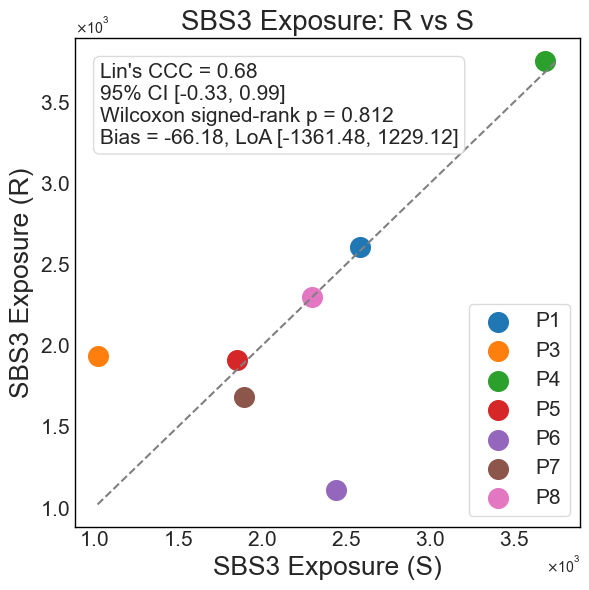

,patient,R,S
0,1,2607.360,2584.770
1,3,1935.813,1022.646
2,4,3756.695,3685.982
3,5,1914.865,1854.761
4,6,1110.379,2439.019
5,7,1686.758,1893.679
6,8,2302.127,2296.392


In [35]:
# Spearman + exact p + CI
# mat_rs, mat_r, mat_s = plot_signature_r_vs_s(
#     sample_dirs, "sbs3", normalise=False,
#     save_path=f"{PLOTSAVEDIR}sbs3_ci",
# )

# Lin's CCC + CI
plot_signature_r_vs_s(
    sample_dirs, "sbs3", normalise=False, show_ccc=True,
    save_path=f"{PLOTSAVEDIR}sbs3_ccc_ci",
    show_paired=True
)